# AI Student Placement Predictor

In [ ]:
## Goal

Predict whether a student will get placed based on academic and skill-related features.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd

In [10]:
import os

os.listdir('/content/drive/MyDrive')

['ML Projects',
 'Emailing Rakshitha Aadhaar Card New.pdf',
 'Emailing DOC-20230415-WA0115..pdf',
 'Emailing Rakshitha_BArch_result (1).pdf',
 'Jee Mains Result Rakshitha .pdf',
 'NATA 2 Admit card Rakshitha .pdf',
 'Emailing RAKSHITHA OBC Certificate.pdf',
 'Emailing Rakshitha_BArch_result.pdf',
 'Emailing NATA 2 Admit card Rakshitha .pdf',
 'Emailing Rakshitha Inter 2nd year Hall Ticket Mar 2023.pdf',
 'Emailing Rakshitha Biometric photo update 18 Jan 2023.pdf',
 'Emailing DOC-20230126-WA0138..pdf',
 'Emailing DOC-20230410-WA0015..pdf',
 'Emailing NATA 2023 Application Form Rakshitha.pdf',
 'Emailing DOC-20230401-WA0109..pdf',
 'Emailing Rakshitha Inter Online Memo 2021 23.pdf',
 'Emailing Rakshitha - JEE (Main) - 2023 Score Card - Application No_ 230310334352 & Roll No. (Session 1)_ TL08000610 & Roll No. (Session 2)_ TL08001546.pdf',
 'Emailing DOC-20230207-WA0018..pdf',
 'Emailing SSC RESULT Rakshitha.pdf',
 'Rakshitha Pan Card.pdf',
 'Voter ID card Rakshitha.pdf',
 'ABC ID (RAKSHI

In [11]:
os.listdir('/content/drive/MyDrive/ML Projects')

['Student Placement Predictor', 'placementdata.csv']

In [12]:
os.listdir('/content/drive/MyDrive/ML Projects/Student Placement Predictor')

['Student_Placement_Predictor.ipynb']

In [13]:
df = pd.read_csv('/content/drive/MyDrive/ML Projects/placementdata.csv')

In [14]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [15]:
df.shape

(10000, 12)

In [16]:
df.columns


Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [18]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [19]:
df.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['PlacementStatus'].value_counts()

,count
PlacementStatus,
NotPlaced,5803
Placed,4197


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

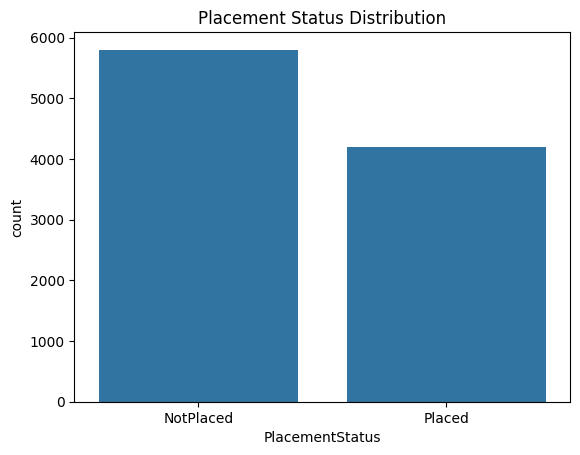

In [23]:
sns.countplot(x='PlacementStatus', data=df)
plt.title('Placement Status Distribution')
plt.show()

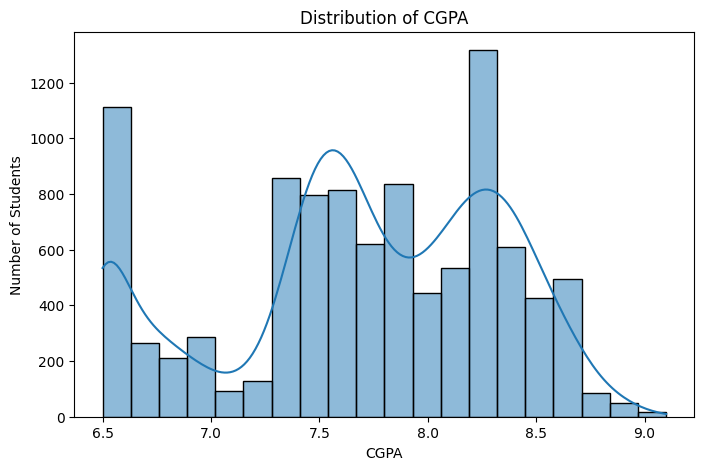

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['CGPA'], bins=20, kde=True)
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Number of Students')
plt.show()

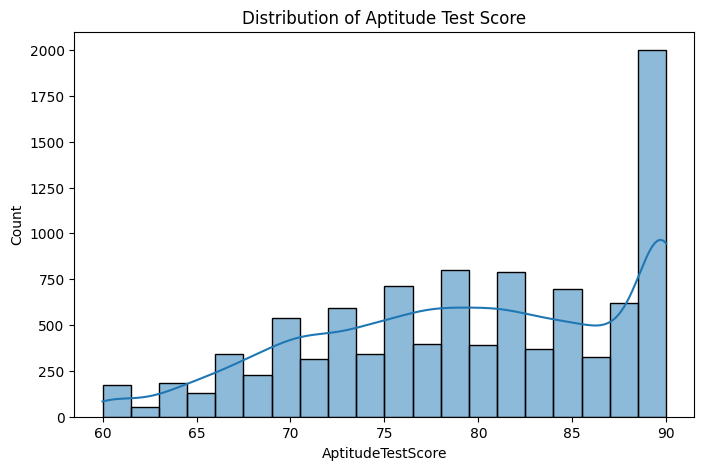

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['AptitudeTestScore'], bins=20, kde=True)
plt.title('Distribution of Aptitude Test Score')
plt.show()

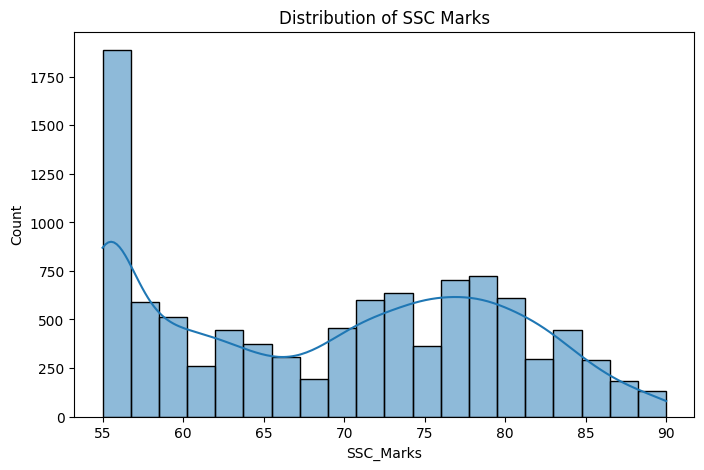

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['SSC_Marks'], bins=20, kde=True)
plt.title('Distribution of SSC Marks')
plt.show()

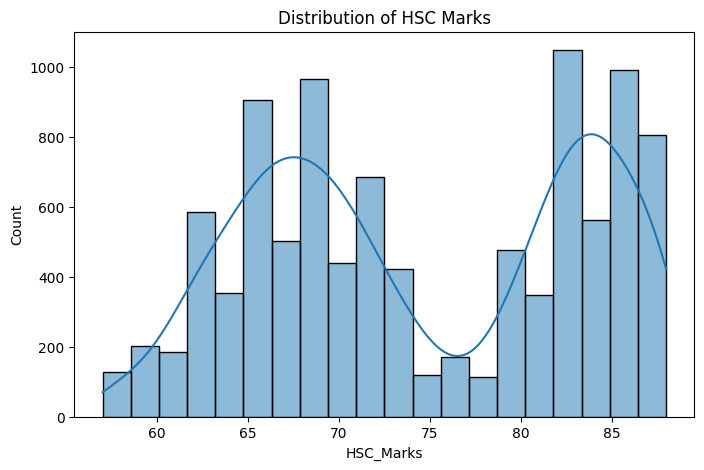

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['HSC_Marks'], bins=20, kde=True)
plt.title('Distribution of HSC Marks')
plt.show()

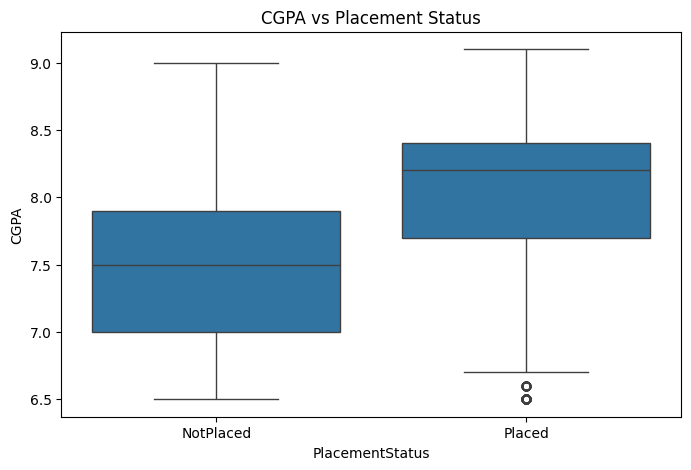

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='PlacementStatus', y='CGPA', data=df)
plt.title('CGPA vs Placement Status')
plt.show()

In [30]:
correlation = df.corr(numeric_only=True)
correlation

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
StudentID,1.000000,0.005724,0.015655,0.015924,0.011872,0.020314,-0.002269,-0.003082,0.024115
CGPA,0.005724,1.000000,0.280601,0.435928,0.349686,0.461250,0.383547,0.404971,0.462313
Internships,0.015655,0.280601,1.000000,0.309196,0.279110,0.320725,0.273691,0.279837,0.317149
Projects,0.015924,0.435928,0.309196,1.000000,0.377865,0.540339,0.450294,0.499421,0.535708
Workshops/Certifications,0.011872,0.349686,0.279110,0.377865,1.000000,0.388061,0.342397,0.373045,0.418442
AptitudeTestScore,0.020314,0.461250,0.320725,0.540339,0.388061,1.000000,0.515400,0.513044,0.565105
SoftSkillsRating,-0.002269,0.383547,0.273691,0.450294,0.342397,0.515400,1.000000,0.430734,0.466912
SSC_Marks,-0.003082,0.404971,0.279837,0.499421,0.373045,0.513044,0.430734,1.000000,0.524916
HSC_Marks,0.024115,0.462313,0.317149,0.535708,0.418442,0.565105,0.466912,0.524916,1.000000


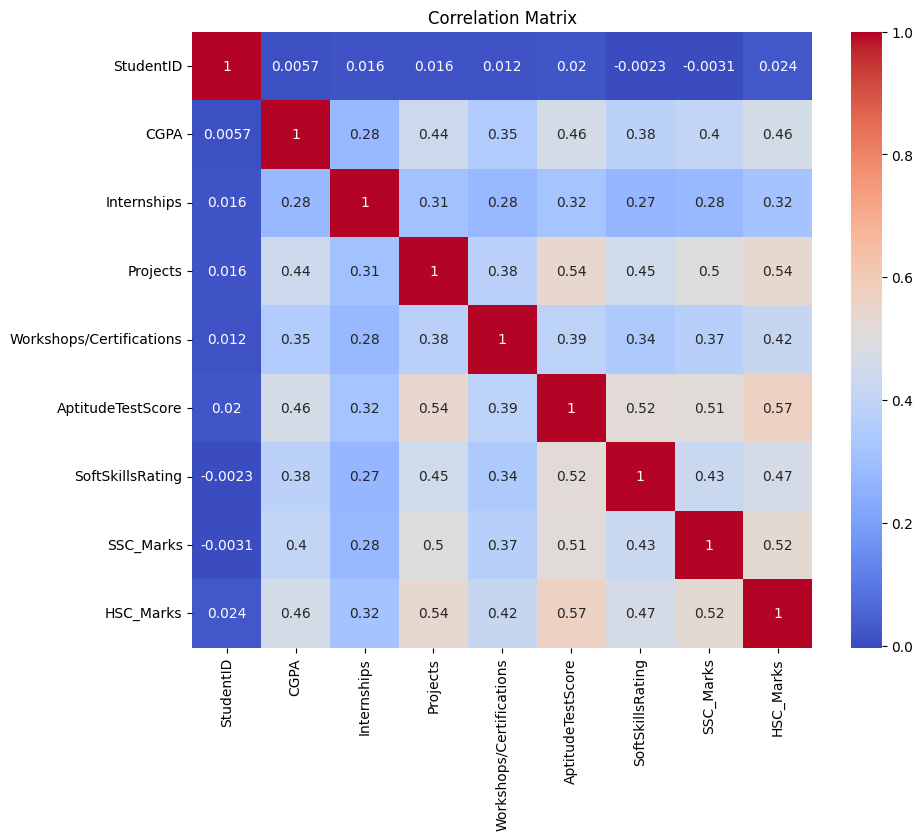

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [32]:
df = df.drop('StudentID', axis=1)

In [33]:
X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [37]:
X.dtypes

,0
CGPA,float64
Internships,int64
Projects,int64
Workshops/Certifications,int64
AptitudeTestScore,int64
SoftSkillsRating,float64
ExtracurricularActivities,object
PlacementTraining,object
SSC_Marks,int64
HSC_Marks,int64


In [38]:
print(df['ExtracurricularActivities'].unique())
print(df['PlacementTraining'].unique())

['No' 'Yes']
['No' 'Yes']


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['ExtracurricularActivities'] = le.fit_transform(df['ExtracurricularActivities'])
df['PlacementTraining'] = le.fit_transform(df['PlacementTraining'])
df['PlacementStatus'] = le.fit_transform(df['PlacementStatus'])

In [40]:
X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7815


In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1172
           1       0.75      0.71      0.73       828

    accuracy                           0.78      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[971 201]
 [236 592]]


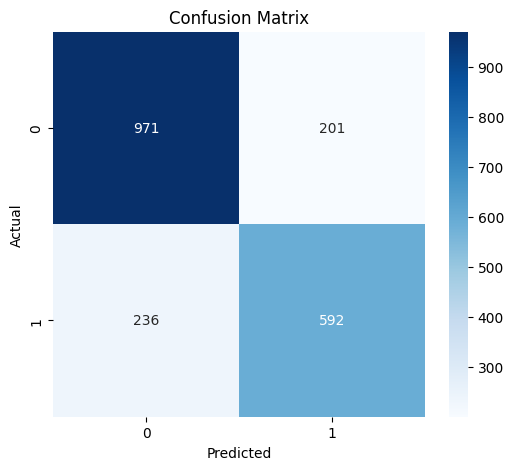

In [66]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [67]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                     Feature  Importance
9                  HSC_Marks    0.211044
4          AptitudeTestScore    0.178484
8                  SSC_Marks    0.133290
0                       CGPA    0.120347
5           SoftSkillsRating    0.094343
2                   Projects    0.073408
6  ExtracurricularActivities    0.072964
3   Workshops/Certifications    0.058424
1                Internships    0.033324
7          PlacementTraining    0.024372


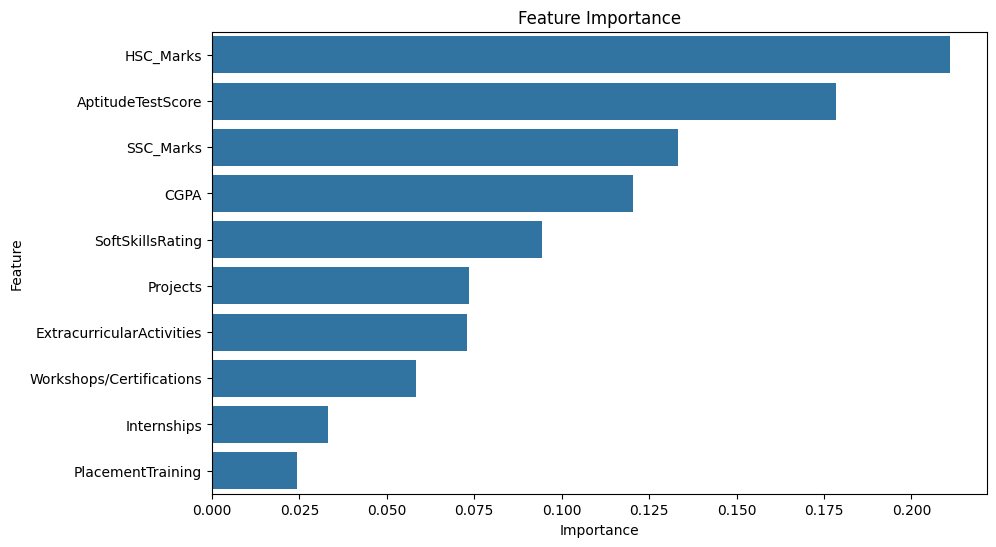

In [68]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [69]:
import joblib

joblib.dump(model, "placement_model.pkl")

['placement_model.pkl']

In [70]:
import os

os.listdir()

['.config', 'placement_model.pkl', 'drive', 'sample_data']

In [71]:
loaded_model = joblib.load("placement_model.pkl")

In [72]:
new_student = [[
    8.5,   # CGPA
    2,     # Internships
    3,     # Projects
    4,     # Workshops/Certifications
    85,    # AptitudeTestScore
    4.2,   # SoftSkillsRating
    1,     # ExtracurricularActivities (Yes = 1)
    1,     # PlacementTraining (Yes = 1)
    90,    # SSC_Marks
    88     # HSC_Marks
]]

prediction = loaded_model.predict(new_student)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [73]:
if prediction[0] == 1:
    print("Placed")
else:
    print("Not Placed")

Placed
